# Mirror Descent and Bregman Divergences

**Mirror descent** generalises gradient descent by replacing the Euclidean proximity term with a **Bregman divergence** $D_\phi(y, x) = \phi(y) - \phi(x) - \langle \nabla\phi(x), y-x\rangle$ induced by a strictly convex **mirror map** $\phi$.

## Mirror descent update

Starting from $x^0 \in \mathrm{dom}\,\phi$, the iterate is:
$$
x^{k+1} = \arg\min_{y} \left\{ \langle \nabla f(x^k), y\rangle + \frac{1}{\tau} D_\phi(y, x^k) \right\} = (\nabla\phi)^{-1}\!\left(\nabla\phi(x^k) - \tau \nabla f(x^k)\right).
$$
The update lives in **dual space**: apply $\nabla f$ in primal, step in dual, map back via $(\nabla\phi)^{-1}$.

## Common mirror maps

| Mirror map $\phi(x)$ | Domain | Dual step $\nabla\phi^{-1}$ | Name |
|---|---|---|---|
| $\frac{1}{2}\|x\|^2$ | $\mathbb{R}^n$ | identity | Gradient descent |
| $\sum_i x_i \log x_i$ | $\Delta_n$ (simplex) | $y_i = \frac{e^{u_i}}{\sum_j e^{u_j}}$ | Exponentiated gradient |
| $-\sum_i \sqrt{x_i}$ | $\mathbb{R}_{>0}^n$ | $y_i = 1/(2u_i)^2$ | sqrt mirror |
| $-\sum_i \log x_i$ | $\mathbb{R}_{>0}^n$ | $y_i = -1/u_i$ | log-barrier mirror |

## Convergence

For a convex $f$ with $L$-Lipschitz gradient (w.r.t.\ $\|\cdot\|_\phi$), mirror descent with step $\tau = R/\sqrt{T}$ achieves:
$$
\min_{k \le T} f(x^k) - f^* \le \frac{R\,G}{\sqrt{T}},
$$
where $R^2 = D_\phi(x^*, x^0)$ and $G$ bounds the dual-norm gradient.

## Constrained optimisation

Mirror descent is particularly powerful when the constraint set $\mathcal{C}$ is compatible with the mirror map — the projection becomes free. On the simplex, **exponentiated gradient** never leaves the simplex by construction.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatLogSlider, Dropdown, IntSlider

plt.rcParams['figure.dpi'] = 120

## Mirror maps and their inverses

We implement four Bregman setups. For visualisation we use a 2D problem on the positive orthant or the simplex.

In [2]:
# ---- Mirror map registry ----

def mirror_euclidean(x, tau_grad):
    """Standard gradient descent step."""
    return x - tau_grad

def mirror_kl(x, tau_grad):
    """Exponentiated gradient: phi = sum x log x, domain = simplex (or R+^n).
    dual update: u = log(x) - tau*grad, then x_new = exp(u) / sum(exp(u)).
    """
    u = np.log(np.maximum(x, 1e-14)) - tau_grad
    x_new = np.exp(u - u.max())   # numerically stable
    return x_new / x_new.sum()

def mirror_sqrt(x, tau_grad):
    """Sqrt mirror: phi = -sum sqrt(x_i), domain R+^n.
    grad phi = -1/(2*sqrt(x)), dual step: u = -1/(2*sqrt(x)) - tau*grad
    inverse: x = 1/(4*u^2) but sign convention: x = 1/(2|u|)^2 for u<0.
    """
    u = -1.0 / (2.0 * np.sqrt(np.maximum(x, 1e-14))) - tau_grad
    return 1.0 / (4.0 * np.maximum(u**2, 1e-14))

def mirror_log(x, tau_grad):
    """Log-barrier: phi = -sum log(x_i), domain R+^n.
    grad phi = -1/x, dual step: u = -1/x - tau*grad
    inverse: x = -1/u (requires u < 0).
    """
    u = -1.0 / np.maximum(x, 1e-14) - tau_grad
    return -1.0 / np.minimum(u, -1e-14)

mirror_fns = {
    'Euclidean (GD)': mirror_euclidean,
    'KL (Exponentiated GD)': mirror_kl,
    'Sqrt mirror': mirror_sqrt,
    'Log-barrier': mirror_log,
}

print('Mirror maps ready.')

Mirror maps ready.


## Objective on the simplex

We minimise $f(x) = \frac{1}{2}\|Ax - b\|^2$ restricted to the probability simplex $\Delta_n = \{x \ge 0,\, \sum x_i = 1\}$. The KL mirror descent (exponentiated gradient) stays on the simplex automatically.

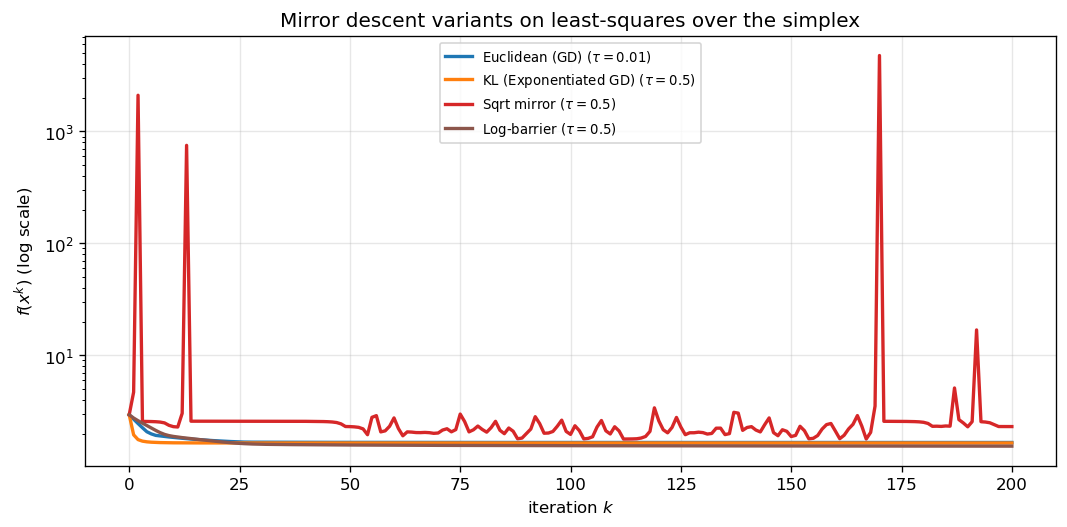

In [3]:
rng = np.random.default_rng(42)
n = 8   # dimension

A = rng.standard_normal((n, n))
b = rng.standard_normal(n)

def f(x):    return 0.5 * np.sum((A @ x - b)**2)
def grad_f(x): return A.T @ (A @ x - b)

def run_mirror(mirror_fn, tau=0.01, n_iter=200):
    x = np.ones(n) / n   # start at centroid of simplex
    hist = [f(x)]
    for _ in range(n_iter):
        g = grad_f(x)
        x = mirror_fn(x, tau * g)
        # Project onto simplex for Euclidean mirror (it doesn't stay there)
        if mirror_fn is mirror_euclidean:
            x = np.maximum(x, 0)
            s = x.sum()
            if s > 0: x /= s
        hist.append(f(x))
    return np.array(hist)

fig, ax = plt.subplots(figsize=(9, 4.5))
tau_vals = {'Euclidean (GD)': 0.01, 'KL (Exponentiated GD)': 0.5,
            'Sqrt mirror': 0.5, 'Log-barrier': 0.5}
cols = plt.cm.tab10(np.linspace(0, 0.5, 4))

for (name, fn), col in zip(mirror_fns.items(), cols):
    tau = tau_vals[name]
    hist = run_mirror(fn, tau=tau)
    ax.semilogy(hist, lw=2, color=col, label=f'{name} ($\\tau={tau}$)')

ax.set_xlabel('iteration $k$'); ax.set_ylabel('$f(x^k)$ (log scale)')
ax.set_title('Mirror descent variants on least-squares over the simplex')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2D visualisation: trajectories on the simplex face

For $n=3$ we can visualise trajectories on the 2-simplex. The KL mirror stays strictly inside; Euclidean gradient descent requires clipping.

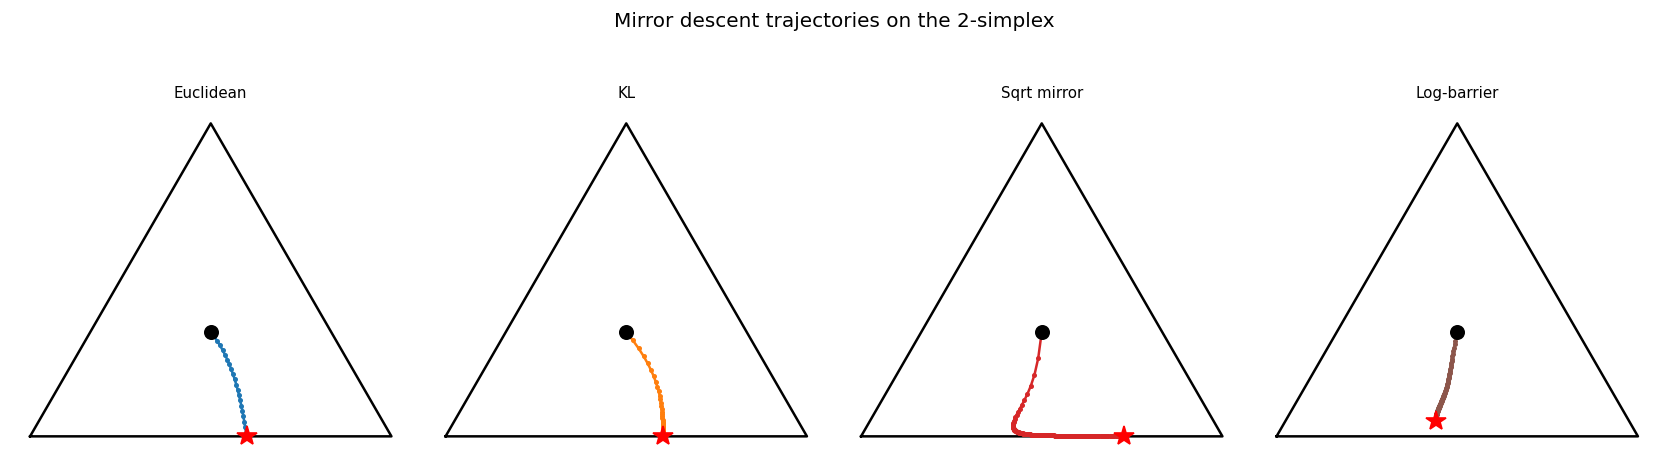

In [4]:
# 3D simplex projected to 2D (barycentric coords)
def simplex_coords(x):
    """Map x in Delta_3 to 2D equilateral triangle coordinates."""
    v0 = np.array([0., 0.])
    v1 = np.array([1., 0.])
    v2 = np.array([0.5, np.sqrt(3)/2])
    return x[0]*v0 + x[1]*v1 + x[2]*v2

n3 = 3
A3 = rng.standard_normal((n3, n3))
b3 = rng.standard_normal(n3)

def f3(x):     return 0.5 * np.sum((A3 @ x - b3)**2)
def grad_f3(x): return A3.T @ (A3 @ x - b3)

def run_mirror_3d(mirror_fn, tau=0.1, n_iter=150):
    x = np.ones(3) / 3
    traj = [simplex_coords(x)]
    for _ in range(n_iter):
        g = grad_f3(x)
        x = mirror_fn(x, tau * g)
        if mirror_fn is mirror_euclidean:
            x = np.maximum(x, 0); s = x.sum()
            if s > 0: x /= s
        traj.append(simplex_coords(x))
    return np.array(traj)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
tau3_vals = [0.05, 0.3, 0.3, 0.3]
cols3 = plt.cm.tab10(np.linspace(0, 0.5, 4))

for ax, (name, fn), tau, col in zip(axes, mirror_fns.items(), tau3_vals, cols3):
    traj = run_mirror_3d(fn, tau=tau)
    # Draw simplex
    tri = np.array([[0,0],[1,0],[0.5, np.sqrt(3)/2],[0,0]])
    ax.plot(tri[:,0], tri[:,1], 'k-', lw=1.5)
    ax.plot(traj[:,0], traj[:,1], '.-', lw=1.5, ms=4, color=col)
    ax.plot(traj[0,0], traj[0,1], 'ko', ms=8)
    ax.plot(traj[-1,0], traj[-1,1], 'r*', ms=12)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(name.split('(')[0].strip(), fontsize=9)

fig.suptitle('Mirror descent trajectories on the 2-simplex', y=1.02)
plt.tight_layout(); plt.show()

## Interactive: compare step sizes

In [5]:
def show_mirror(mirror_name='KL (Exponentiated GD)', log_tau=-1.0, n_iter=200):
    fn = mirror_fns[mirror_name]
    tau = 10**log_tau
    hist = run_mirror(fn, tau=tau, n_iter=n_iter)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(hist, 'royalblue', lw=2)
    ax.set_xlabel('iteration'); ax.set_ylabel('$f(x^k)$')
    ax.set_title(f'{mirror_name}  |  $\\tau={tau:.3f}$  |  final $f={hist[-1]:.4f}$')
    ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

interact(show_mirror,
         mirror_name=Dropdown(options=list(mirror_fns.keys()), description='Mirror'),
         log_tau=FloatLogSlider(value=-1.0, min=-3.0, max=1.0, step=0.25, description='$\\log_{10}\\tau$'),
         n_iter=IntSlider(value=200, min=50, max=600, step=50, description='iters'));

interactive(children=(Dropdown(description='Mirror', options=('Euclidean (GD)', 'KL (Exponentiated GD)', 'Sqrt…

## Bibliographical resources

- Nemirovsky, A. S. and Yudin, D. B. (1983). *Problem Complexity and Method Efficiency in Optimization*. Wiley.
- Beck, A. and Teboulle, M. (2003). Mirror descent and nonlinear projected subgradient methods. *Operations Research Letters*, 31(3), 167–175.
- Kivinen, J. and Warmuth, M. K. (1997). Exponentiated gradient versus gradient descent for linear predictors. *Information and Computation*, 132(1), 1–63.
- Bregman, L. M. (1967). The relaxation method of finding the common point of convex sets and its application. *USSR Computational Mathematics and Mathematical Physics*, 7(3), 200–217.
- Bubeck, S. (2015). Convex optimization: Algorithms and complexity. *Foundations and Trends in Machine Learning*, 8(3–4), 231–357.